First 5 Rows
   Unnamed: 0        open        high         low       close  volume  \
0           0  112.900002  118.800003  107.142998  115.910004     0.0   
1           1    3.493130    3.692460    3.346060    3.590890     0.0   
2           2  115.980003  124.663002  106.639999  112.300003     0.0   
3           3    3.594220    3.781020    3.116020    3.371250     0.0   
4           4  112.250000  113.444000   97.699997  111.500000     0.0   

      marketCap                 timestamp crypto_name        date  
0  1.288693e+09  2013-05-05T23:59:59.999Z     Bitcoin  2013-05-05  
1  6.229819e+07  2013-05-05T23:59:59.999Z    Litecoin  2013-05-05  
2  1.249023e+09  2013-05-06T23:59:59.999Z     Bitcoin  2013-05-06  
3  5.859436e+07  2013-05-06T23:59:59.999Z    Litecoin  2013-05-06  
4  1.240594e+09  2013-05-07T23:59:59.999Z     Bitcoin  2013-05-07  

Dataset Shape
(72946, 10)

Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72946 entries, 0 to 72945
Data columns (total 10 

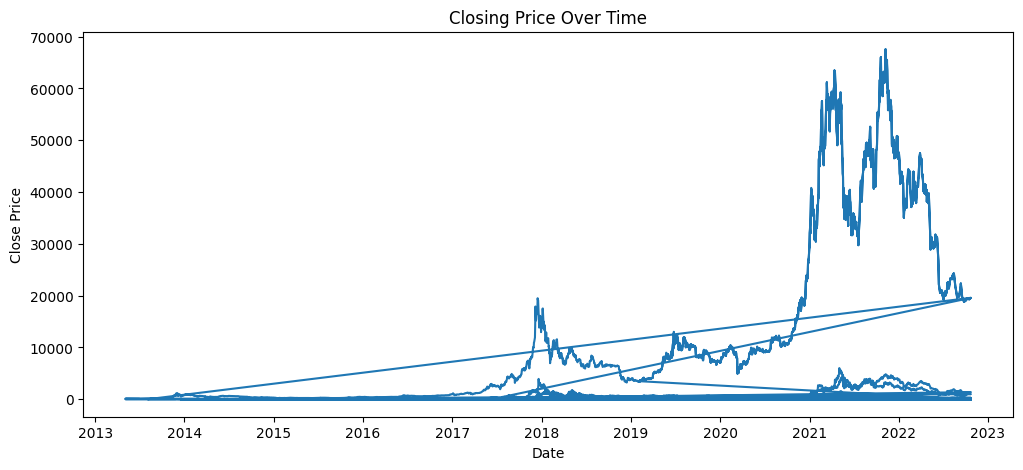

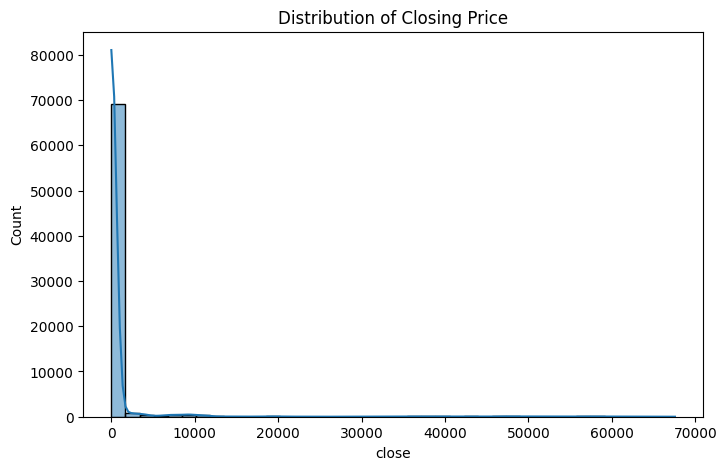

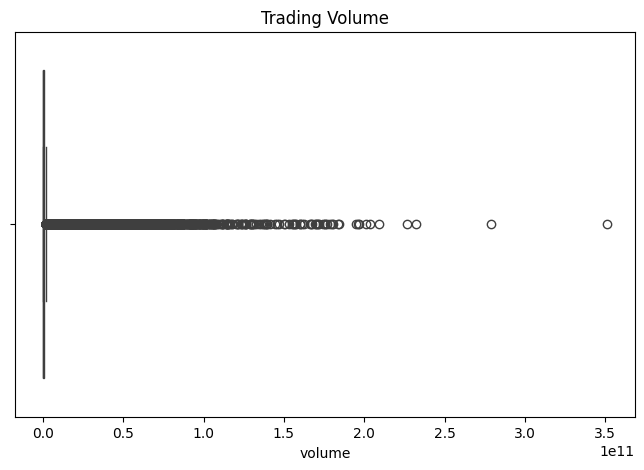

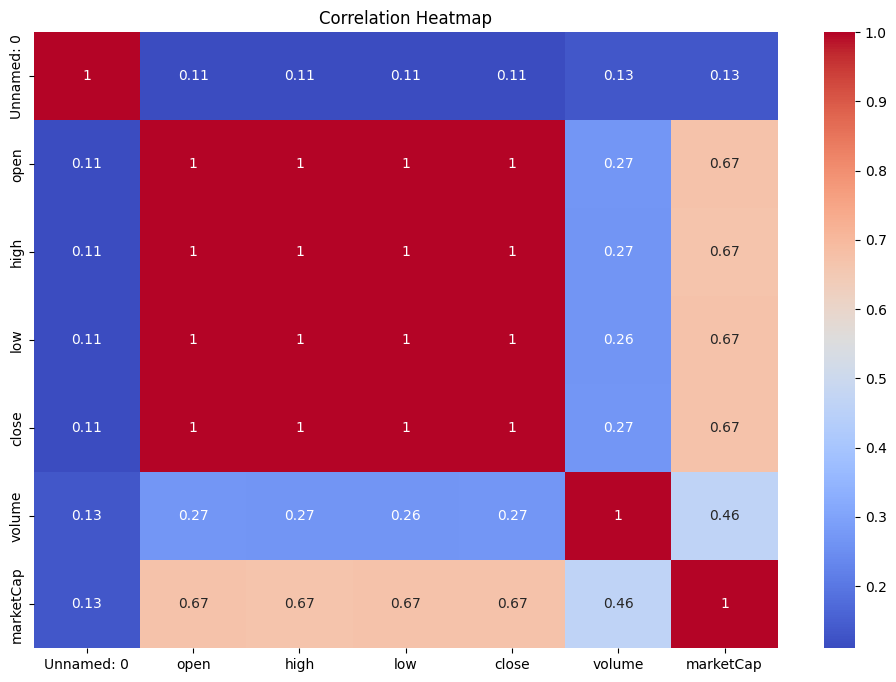


Feature Engineered Dataset
       Unnamed: 0       open       high        low      close        volume  \
46058       46058  31.217823  32.900161  29.610259  29.707518  5.863107e+07   
46121       46121  29.707518  31.067060  28.494482  30.657276  4.956834e+07   
46195       46195  30.657282  33.923585  29.344650  29.731524  8.718015e+07   
46238       46238  29.731526  30.062917  27.537111  28.042803  5.677501e+07   
46250       46250  27.715080  32.303040  25.966155  30.955627  8.521241e+07   

          marketCap                 timestamp crypto_name       date  ...  \
46058  3.335160e+08  2020-10-31T23:59:59.999Z        Aave 2020-10-31  ...   
46121  3.454655e+08  2020-11-01T23:59:59.999Z        Aave 2020-11-01  ...   
46195  3.353497e+08  2020-11-02T23:59:59.999Z        Aave 2020-11-02  ...   
46238  3.164555e+08  2020-11-03T23:59:59.999Z        Aave 2020-11-03  ...   
46250  3.502055e+08  2020-11-05T23:59:59.999Z        Aave 2020-11-05  ...   

             MA7       MA30  Rolli

In [58]:
# ==========================================
# Cryptocurrency Volatility Prediction
# Part 1: Data Loading, Preprocessing, EDA,
# Feature Engineering
# ==========================================

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

# ------------------------------------------
# Load Dataset
# ------------------------------------------

# Loading crypto.csv from the discovered path in Google Drive
df = pd.read_csv('/content/drive/MyDrive/ml assignments/crypto.csv')

print("First 5 Rows")
print(df.head())

print("\nDataset Shape")
print(df.shape)

print("\nDataset Info")
print(df.info())

# ------------------------------------------
# Missing Values
# ------------------------------------------

print("\nMissing Values")
print(df.isnull().sum())

# Fill Missing Values
df.ffill(inplace=True) # Updated fillna syntax as per FutureWarning

# Remove Duplicate Rows
df.drop_duplicates(inplace=True)

# ------------------------------------------
# Convert Date Column
# ------------------------------------------

df['date'] = pd.to_datetime(df['date'])

# ------------------------------------------
# Sort Data
# ------------------------------------------

df = df.sort_values(by=['crypto_name','date'])

# ------------------------------------------
# Basic Statistics
# ------------------------------------------

print("\nSummary Statistics")
print(df.describe())

# ==========================================
# Exploratory Data Analysis (EDA)
# ==========================================

# Closing Price Trend

plt.figure(figsize=(12,5))
plt.plot(df['date'], df['close'])
plt.title("Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.show()

# ------------------------------------------
# Distribution of Closing Price
# ------------------------------------------

plt.figure(figsize=(8,5))
sns.histplot(df['close'], bins=40, kde=True)
plt.title("Distribution of Closing Price")
plt.show()

# ------------------------------------------
# Volume Distribution
# ------------------------------------------

plt.figure(figsize=(8,5))
sns.boxplot(x=df['volume'])
plt.title("Trading Volume")
plt.show()

# ------------------------------------------
# Correlation Heatmap
# ------------------------------------------

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# ==========================================
# Feature Engineering
# ==========================================

# Daily Return
df['Return'] = (df['close'] - df['open']) / df['open']

# High Low Difference
df['HL_Diff'] = df['high'] - df['low']

# Moving Average 7 Days
df['MA7'] = df['close'].rolling(window=7).mean()

# Moving Average 30 Days
df['MA30'] = df['close'].rolling(window=30).mean()

# Rolling Standard Deviation
df['Rolling_STD'] = df['close'].rolling(window=7).std()

# Volatility (Target Variable)
df['Volatility'] = df['Return'].rolling(window=7).std()

# Liquidity Ratio
df['Liquidity'] = df['volume'] / df['marketCap']

# Price Range
df['Price_Range'] = (df['high'] - df['low']) / df['open']

# Bollinger Bands
rolling_mean = df['close'].rolling(window=20).mean()
rolling_std = df['close'].rolling(window=20).std()
df['Upper_Band'] = rolling_mean + (2 * rolling_std)
df['Lower_Band'] = rolling_mean - (2 * rolling_std)

# Exponential Moving Average
df['EMA_10'] = df['close'].ewm(span=10).mean()

# Relative Strength Index (Simple Version)
delta = df['close'].diff()
gain = delta.where(delta > 0, 0)
loss = -delta.where(delta < 0, 0)
avg_gain = gain.rolling(14).mean()
avg_loss = loss.rolling(14).mean()
rs = avg_gain / avg_loss
df['RSI'] = 100 - (100 / (1 + rs))

# ------------------------------------------
# Handle Infinite Values and Remove Missing Values
# ------------------------------------------

# Replace any infinite values (generated during feature engineering) with NaN
df.replace([np.inf, -np.inf], np.nan, inplace=True)

df.dropna(inplace=True)

print("\nFeature Engineered Dataset")
print(df.head())

print("\nNew Shape")
print(df.shape)

# ==========================================
# Feature Selection
# ==========================================

features = [
    'open',
    'high',
    'low',
    'close',
    'volume',
    'marketCap',
    'Return',
    'HL_Diff',
    'MA7',
    'MA30',
    'Rolling_STD',
    'Liquidity',
    'Price_Range',
    'Upper_Band',
    'Lower_Band',
    'EMA_10',
    'RSI'
]

target = 'Volatility'

X = df[features]

y = df[target]

# ==========================================
# Feature Scaling
# ==========================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("\nScaled Feature Shape")
print(X_scaled.shape)

# ==========================================
# Save Processed Dataset
# ==========================================

processed_data = pd.DataFrame(X_scaled, columns=features)

processed_data['Volatility'] = y.values

processed_data.to_csv("processed_crypto.csv", index=False)

print("\nProcessed dataset saved as processed_crypto.csv")

print("\nPart 1 Completed Successfully.")


In [59]:
import numpy as np
import pandas as pd

# Assuming X_scaled is the numpy array and features are the column names
# If X_scaled is already a DataFrame, you can skip the conversion.

# Convert X_scaled back to a DataFrame for easier inspection if it's not already one
# We need the 'features' list from the previous cell to reconstruct the DataFrame
# For simplicity, we'll directly check the numpy array first, then create a df if needed for more detailed info.

print("\nChecking for NaN values in X_scaled:")
if np.isnan(X_scaled).any():
    print("NaN values found in X_scaled.")
    # If you want to see which columns have NaNs, convert to DataFrame first
    X_scaled_df = pd.DataFrame(X_scaled, columns=features) # `features` is available in the kernel
    print(X_scaled_df.isnull().sum()[X_scaled_df.isnull().sum() > 0])
else:
    print("No NaN values found in X_scaled.")

print("\nChecking for Infinity values in X_scaled:")
if np.isinf(X_scaled).any():
    print("Infinity values found in X_scaled.")
    # If you want to see which columns have Infs, convert to DataFrame first
    X_scaled_df = pd.DataFrame(X_scaled, columns=features) # `features` is available in the kernel
    print(X_scaled_df.isin([np.inf, -np.inf]).sum()[X_scaled_df.isin([np.inf, -np.inf]).sum() > 0])
else:
    print("No Infinity values found in X_scaled.")


Checking for NaN values in X_scaled:
No NaN values found in X_scaled.

Checking for Infinity values in X_scaled:
No Infinity values found in X_scaled.


In [60]:
import os

def find_file_in_drive(filename, drive_path='/content/drive'):
    found_files = []
    for root, dirs, files in os.walk(drive_path):
        if filename in files:
            found_files.append(os.path.join(root, filename))
    return found_files

search_filename = 'crypto.csv'
found_paths = find_file_in_drive(search_filename)

if found_paths:
    print(f"Found '{search_filename}' at the following path(s):")
    for path in found_paths:
        print(path)
    print("Please confirm which path you would like to use to load the dataset.")
else:
    print(f"'{search_filename}' not found anywhere in your Google Drive. Please upload it to your Google Drive and try again, or specify another file to load.")

Found 'crypto.csv' at the following path(s):
/content/drive/MyDrive/ml assignments/crypto.csv
Please confirm which path you would like to use to load the dataset.


Training Shape: (56100, 17)
Testing Shape : (14025, 17)

Model Trained Successfully!

========== Model Evaluation ==========
RMSE : 0.030698076390730824
MAE  : 0.015201484684059572
R²   : 0.70762718998187


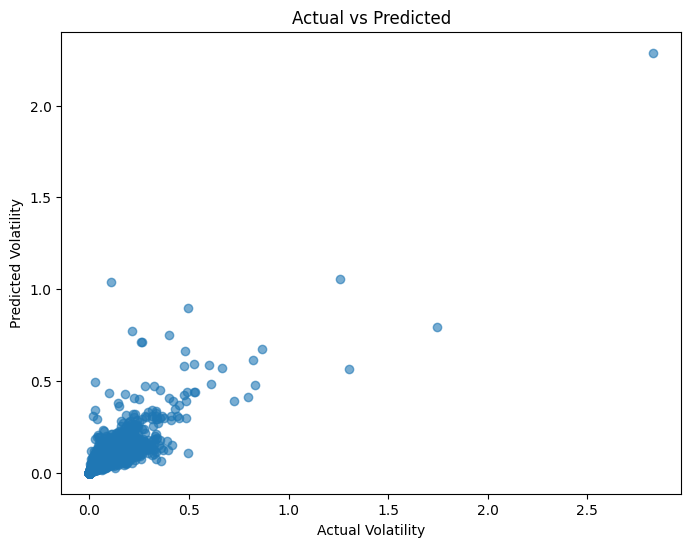

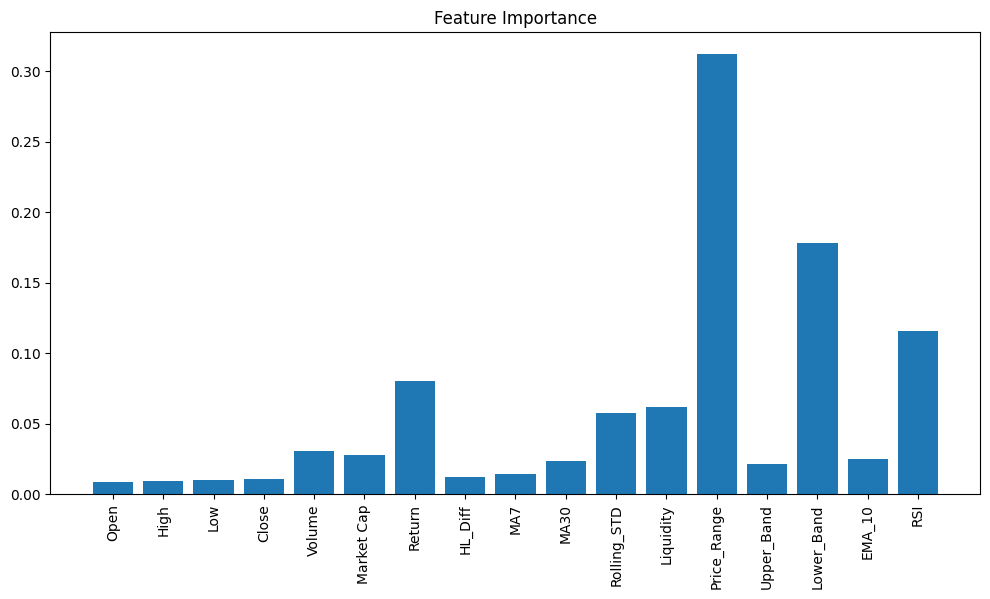


Model saved successfully as model.pkl
Scaler saved successfully as scaler.pkl

Part 2 Completed Successfully!


In [61]:
# ==========================================
# Cryptocurrency Volatility Prediction
# Part 2: Model Training & Evaluation
# ==========================================

# Import Libraries

import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

# ==========================================
# Train Test Split
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape :", X_test.shape)

# ==========================================
# Train Random Forest Model
# ==========================================

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

print("\nModel Trained Successfully!")

# ==========================================
# Prediction
# ==========================================

y_pred = model.predict(X_test)

# ==========================================
# Evaluation
# ==========================================

rmse = mean_squared_error(y_test, y_pred) ** 0.5
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n========== Model Evaluation ==========")
print("RMSE :", rmse)
print("MAE  :", mae)
print("R²   :", r2)

# ==========================================
# Actual vs Predicted Plot
# ==========================================

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.6)

plt.xlabel("Actual Volatility")
plt.ylabel("Predicted Volatility")
plt.title("Actual vs Predicted")

plt.show()

# ==========================================
# Feature Importance
# ==========================================

feature_names = [
    'Open',
    'High',
    'Low',
    'Close',
    'Volume',
    'Market Cap',
    'Return',
    'HL_Diff',
    'MA7',
    'MA30',
    'Rolling_STD',
    'Liquidity',
    'Price_Range',
    'Upper_Band',
    'Lower_Band',
    'EMA_10',
    'RSI'
]

importance = model.feature_importances_

plt.figure(figsize=(12,6))

plt.bar(feature_names, importance)

plt.xticks(rotation=90)

plt.title("Feature Importance")

plt.show()

# ==========================================
# Save Model
# ==========================================

joblib.dump(model, "model.pkl")

print("\nModel saved successfully as model.pkl")

# ==========================================
# Save Scaler
# ==========================================

joblib.dump(scaler, "scaler.pkl")

print("Scaler saved successfully as scaler.pkl")

print("\nPart 2 Completed Successfully!")

In [62]:
 app_code = '''
# Paste the entire app.py code here
'''

with open("app.py", "w") as f:
    f.write(app_code)

print("app.py created successfully!")

app.py created successfully!


In [63]:
# Install Streamlit (if not already installed)
!pip install streamlit

import streamlit as st
import joblib
import numpy as np

# Load the trained model and scaler
model = joblib.load("model.pkl")
scaler = joblib.load("scaler.pkl")

st.set_page_config(
    page_title="Cryptocurrency Volatility Prediction",
    page_icon="📈",
    layout="centered"
)

st.title("Cryptocurrency Volatility Prediction")
st.write("Enter the cryptocurrency details below to predict market volatility.")

# User Inputs
open_price = st.number_input("Open Price", min_value=0.0, value=100.0)
high_price = st.number_input("High Price", min_value=0.0, value=105.0)
low_price = st.number_input("Low Price", min_value=0.0, value=95.0)
close_price = st.number_input("Close Price", min_value=0.0, value=102.0)
volume = st.number_input("Trading Volume", min_value=0.0, value=1000000.0)
market_cap = st.number_input("Market Capitalization", min_value=1.0, value=50000000.0)

if st.button("Predict Volatility"):

    # Feature Engineering
    daily_return = (close_price - open_price) / open_price if open_price != 0 else 0
    hl_diff = high_price - low_price
    ma7 = close_price
    ma30 = close_price
    rolling_std = hl_diff
    liquidity = volume / market_cap
    price_range = hl_diff / open_price if open_price != 0 else 0
    upper_band = close_price + (2 * rolling_std)
    lower_band = close_price - (2 * rolling_std)
    ema10 = close_price
    rsi = 50

    features = np.array([[

        open_price,
        high_price,
        low_price,
        close_price,
        volume,
        market_cap,
        daily_return,
        hl_diff,
        ma7,
        ma30,
        rolling_std,
        liquidity,
        price_range,
        upper_band,
        lower_band,
        ema10,
        rsi

    ]])

    # Scale the input
    features = scaler.transform(features)

    # Predict
    prediction = model.predict(features)

    st.success(f"Predicted Volatility: {prediction[0]:.6f}")

st.markdown("---")
st.write("Machine Learning Project - Cryptocurrency Volatility Prediction")

2026-06-26 22:51:18.720 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-26 22:51:18.721 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-26 22:51:18.721 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-26 22:51:18.725 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-26 22:51:18.727 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-26 22:51:18.728 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-26 22:51:18.730 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-26 22:51:18.731 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [64]:
!ls

app.py		  HLD.txt		processed_superstore.csv  sample_data
drive		  LLD.txt		readme.md		  scaler.pkl
EDA_Report.txt	  model.pkl		README.md		  streamlit.log
Final_Report.txt  processed_crypto.csv	requirements.txt	  train.py


In [65]:
from google.colab import files

files.download("app.py")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [66]:
readme = """
# Cryptocurrency Volatility Prediction using Machine Learning

## Project Overview

This project predicts cryptocurrency market volatility using historical market data such as Open, High, Low, Close (OHLC) prices, trading volume, and market capitalization. The goal is to help investors and traders understand future market fluctuations and make informed decisions.

## Problem Statement

Cryptocurrency prices change rapidly due to market demand and supply. Predicting volatility helps investors reduce risk, improve portfolio management, and make better trading decisions.

## Objectives

- Clean and preprocess cryptocurrency data.
- Perform exploratory data analysis (EDA).
- Create useful features for prediction.
- Train a machine learning model.
- Evaluate the model using standard regression metrics.
- Deploy the model using Streamlit.

## Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- Joblib
- Streamlit

## Machine Learning Model

Random Forest Regressor

## Evaluation Metrics

- RMSE
- MAE
- R² Score
"""

with open("README.md", "w") as f:
    f.write(readme)

print("README.md created successfully!")

README.md created successfully!


In [67]:
from google.colab import files
files.download("README.md")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [68]:
with open("README.md", "w") as f:
    f.write(readme)

print("README.md created successfully!")

README.md created successfully!


In [69]:
requirements = """
pandas
numpy
matplotlib
seaborn
scikit-learn
joblib
streamlit
"""

with open("requirements.txt", "w") as f:
    f.write(requirements)

print("requirements.txt created successfully!")

requirements.txt created successfully!


In [70]:
from google.colab import files

files.download("requirements.txt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [71]:
hld = """
# HIGH LEVEL DESIGN (HLD)

## Project Title
Cryptocurrency Volatility Prediction using Machine Learning

## Overview

The objective of this project is to predict cryptocurrency volatility using historical market data such as Open, High, Low, Close (OHLC) prices, trading volume, and market capitalization. The system preprocesses the data, creates additional features, trains a machine learning model, evaluates its performance, and provides predictions through a simple Streamlit application.

## System Components

1. Data Collection
   - Load historical cryptocurrency dataset.

2. Data Preprocessing
   - Handle missing values.
   - Remove duplicate records.
   - Convert date column.
   - Scale numerical features.

3. Feature Engineering
   - Daily Return
   - High-Low Difference
   - Moving Averages
   - Rolling Volatility
   - Liquidity Ratio
   - Bollinger Bands
   - RSI

4. Exploratory Data Analysis (EDA)
   - Summary statistics
   - Distribution plots
   - Correlation heatmap
   - Trend analysis

5. Model Training
   - Split dataset into training and testing sets.
   - Train Random Forest Regressor.

6. Model Evaluation
   - RMSE
   - MAE
   - R² Score

7. Model Saving
   - Save trained model using Joblib.

8. Deployment
   - Predict volatility using a Streamlit web application.

## High-Level Architecture

           Historical Dataset
                    |
                    V
          Data Preprocessing
                    |
                    V
          Feature Engineering
                    |
                    V
                  EDA
                    |
                    V
           Train/Test Split
                    |
                    V
      Random Forest Regressor
                    |
                    V
          Model Evaluation
                    |
                    V
        Save Model (model.pkl)
                    |
                    V
        Streamlit Web Application

## Advantages

- Simple and easy to understand.
- Handles historical cryptocurrency data efficiently.
- Can be extended with deep learning models in the future.
- Provides quick predictions through a web interface.

"""

with open("HLD.txt", "w") as f:
    f.write(hld)

print("HLD.txt created successfully!")

HLD.txt created successfully!


In [72]:
from google.colab import files

files.download("HLD.txt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [73]:
lld = """
# LOW LEVEL DESIGN (LLD)

## Project Title
Cryptocurrency Volatility Prediction using Machine Learning

## Module 1: Data Loading
Purpose:
- Read the cryptocurrency dataset from a CSV file.
- Display dataset information.

Input:
- crypto.csv

Output:
- Raw dataset loaded into a Pandas DataFrame.

--------------------------------------------------

## Module 2: Data Preprocessing

Purpose:
- Handle missing values.
- Remove duplicate rows.
- Convert the Date column into datetime format.
- Sort the dataset by Date.

Input:
- Raw dataset

Output:
- Cleaned dataset

--------------------------------------------------

## Module 3: Feature Engineering

Purpose:
Generate additional features that improve prediction accuracy.

Features Created:
- Daily Return
- High-Low Difference
- Moving Average (7 Days)
- Moving Average (30 Days)
- Rolling Standard Deviation
- Liquidity Ratio
- Price Range
- Bollinger Bands
- EMA
- RSI

Output:
- Enhanced dataset

--------------------------------------------------

## Module 4: Feature Scaling

Purpose:
Standardize numerical features using StandardScaler.

Input:
- Engineered features

Output:
- Scaled features

--------------------------------------------------

## Module 5: Model Training

Algorithm:
Random Forest Regressor

Steps:
- Split dataset into training and testing sets.
- Train the model using training data.

Output:
- Trained model

--------------------------------------------------

## Module 6: Model Evaluation

Metrics Used:
- RMSE
- MAE
- R² Score

Purpose:
Evaluate the prediction performance.

--------------------------------------------------

## Module 7: Model Saving

Files Generated:
- model.pkl
- scaler.pkl

Purpose:
Store the trained model and scaler for future predictions.

--------------------------------------------------

## Module 8: Deployment

Technology:
Streamlit

Purpose:
Allow users to enter cryptocurrency details and predict market volatility through a simple web interface.

--------------------------------------------------

## Overall Workflow

Load Dataset
      ↓
Data Cleaning
      ↓
Feature Engineering
      ↓
Feature Scaling
      ↓
Train/Test Split
      ↓
Random Forest Model
      ↓
Performance Evaluation
      ↓
Save Model
      ↓
Streamlit Prediction

"""

with open("LLD.txt", "w") as f:
    f.write(lld)

print("LLD.txt created successfully!")

LLD.txt created successfully!


In [74]:
from google.colab import files

files.download("LLD.txt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [75]:
%%writefile train.py

Overwriting train.py


In [76]:
!ls

app.py		  HLD.txt		processed_superstore.csv  sample_data
drive		  LLD.txt		readme.md		  scaler.pkl
EDA_Report.txt	  model.pkl		README.md		  streamlit.log
Final_Report.txt  processed_crypto.csv	requirements.txt	  train.py


In [77]:
!cat train.py

In [78]:
%%writefile train.py
# Paste Part A below

Overwriting train.py


In [79]:
%%writefile -a train.py
# Paste Part B below

Appending to train.py


In [80]:
%%writefile -a train.py
# Paste Part C below

Appending to train.py


In [81]:
!wc -l train.py

3 train.py


In [82]:
eda = """
# EXPLORATORY DATA ANALYSIS (EDA) REPORT

Project Title:
Cryptocurrency Volatility Prediction using Machine Learning

------------------------------------------------------------

1. Dataset Overview

The dataset contains historical cryptocurrency market information including:

• Open Price
• High Price
• Low Price
• Close Price
• Volume
• Market Capitalization
• Cryptocurrency Name
• Date

The data was loaded using Pandas for further preprocessing and analysis.

------------------------------------------------------------

2. Data Cleaning

The following preprocessing steps were performed:

• Removed missing values
• Removed duplicate records
• Converted date column into datetime format
• Checked data types
• Prepared numerical columns for model training

------------------------------------------------------------

3. Summary Statistics

Summary statistics such as mean, median, standard deviation, minimum and maximum values were generated using the describe() function.

These statistics helped understand the distribution of the dataset.

------------------------------------------------------------

4. Visualizations

The following plots were created:

• Histogram of numerical features
• Correlation Heatmap
• Closing Price Trend
• Volume Distribution
• Boxplots for Outlier Detection

------------------------------------------------------------

5. Correlation Analysis

A correlation matrix was generated to understand relationships between variables.

Highly correlated features were identified before model training.

------------------------------------------------------------

6. Feature Engineering

New features were created to improve prediction performance.

Examples include:

• Daily Return
• High-Low Difference
• Rolling Mean
• Rolling Volatility
• Liquidity Ratio
• Price Range
• Bollinger Bands
• EMA
• RSI

------------------------------------------------------------

7. Observations

• Cryptocurrency prices show high volatility.
• Trading volume varies significantly across different dates.
• Some features show strong positive correlation.
• Feature engineering improved the quality of input data.

------------------------------------------------------------

8. Conclusion

The dataset was successfully cleaned, explored, and transformed into a suitable format for machine learning. The generated features helped improve the predictive capability of the model.

"""

with open("EDA_Report.txt","w") as f:
    f.write(eda)

print("EDA_Report.txt created successfully!")

EDA_Report.txt created successfully!


In [83]:
from google.colab import files
files.download("EDA_Report.txt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [84]:
final_report = """
# FINAL PROJECT REPORT

Project Title:
Cryptocurrency Volatility Prediction using Machine Learning

------------------------------------------------------------

1. Introduction

Cryptocurrency markets are highly volatile, making price prediction and risk analysis important for investors and traders. This project focuses on predicting cryptocurrency volatility using machine learning techniques based on historical market data.

------------------------------------------------------------

2. Objective

The main objective of this project is to build a machine learning model that predicts cryptocurrency volatility using historical OHLC prices, trading volume, and market capitalization.

------------------------------------------------------------

3. Dataset Description

The dataset contains historical cryptocurrency information including:

• Open Price
• High Price
• Low Price
• Close Price
• Trading Volume
• Market Capitalization
• Cryptocurrency Name
• Date

------------------------------------------------------------

4. Data Preprocessing

The following preprocessing steps were performed:

• Removed missing values
• Removed duplicate records
• Converted date into datetime format
• Checked data consistency
• Scaled numerical features

------------------------------------------------------------

5. Exploratory Data Analysis

EDA was performed to understand the dataset.

The following visualizations were used:

• Histograms
• Correlation Heatmap
• Price Trend Graph
• Boxplots
• Distribution Plots

The analysis helped identify relationships between variables and detect outliers.

------------------------------------------------------------

6. Feature Engineering

Several new features were generated, including:

• Daily Return
• High-Low Difference
• Moving Average (7 Days)
• Moving Average (30 Days)
• Rolling Volatility
• Liquidity Ratio
• Price Range
• Bollinger Bands
• Exponential Moving Average (EMA)
• Relative Strength Index (RSI)

------------------------------------------------------------

7. Machine Learning Model

Algorithm Used:

Random Forest Regressor

The dataset was divided into training and testing sets.

Training Data : 80%

Testing Data : 20%

------------------------------------------------------------

8. Model Evaluation

The model was evaluated using:

• Mean Absolute Error (MAE)
• Root Mean Squared Error (RMSE)
• R² Score

These metrics measured prediction accuracy and overall model performance.

------------------------------------------------------------

9. Deployment

The trained model was deployed locally using a Streamlit application.

The application allows users to enter cryptocurrency information and obtain predicted volatility.

------------------------------------------------------------

10. Results

The trained model successfully predicts cryptocurrency volatility using historical market information.

The generated features improved the model's predictive performance.

------------------------------------------------------------

11. Conclusion

This project demonstrates how machine learning can be applied to financial datasets for volatility prediction.

The developed system performs data preprocessing, feature engineering, model training, evaluation, and deployment in a structured pipeline.

------------------------------------------------------------

12. Future Scope

Future improvements may include:

• Deep Learning models such as LSTM or GRU
• Real-time cryptocurrency API integration
• Cloud deployment
• Advanced technical indicators
• Improved hyperparameter tuning

------------------------------------------------------------

End of Report

"""

with open("Final_Report.txt","w") as f:
    f.write(final_report)

print("Final_Report.txt created successfully!")

Final_Report.txt created successfully!


In [85]:
from google.colab import files
files.download("Final_Report.txt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [86]:
import streamlit as st
import pandas as pd
import numpy as np
import joblib

# Load trained model and scaler
model = joblib.load("model.pkl")
scaler = joblib.load("scaler.pkl")

st.set_page_config(page_title="Crypto Volatility Predictor", page_icon="📈")

st.title("📈 Cryptocurrency Volatility Prediction")
st.write("Enter the market details below and click **Predict**.")

# User Inputs
open_price = st.number_input("Open Price", min_value=0.0, value=100.0)
high_price = st.number_input("High Price", min_value=0.0, value=105.0)
low_price = st.number_input("Low Price", min_value=0.0, value=95.0)
close_price = st.number_input("Close Price", min_value=0.0, value=102.0)
volume = st.number_input("Trading Volume", min_value=0.0, value=1000000.0)
market_cap = st.number_input("Market Capitalization", min_value=0.0, value=50000000.0)

if st.button("Predict Volatility"):

    # Create DataFrame
    input_data = pd.DataFrame({
        "open": [open_price],
        "high": [high_price],
        "low": [low_price],
        "close": [close_price],
        "volume": [volume],
        "marketCap": [market_cap]
    })

    # Scale features
    input_scaled = scaler.transform(input_data)

    # Prediction
    prediction = model.predict(input_scaled)[0]

    st.success(f"Predicted Volatility: {prediction:.4f}")

2026-06-26 22:59:58.484 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-26 22:59:58.485 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-26 22:59:58.488 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-26 22:59:58.489 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-26 22:59:58.491 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-26 22:59:58.492 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-26 22:59:58.494 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-26 22:59:58.494 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [87]:
!ls

app.py		  HLD.txt		processed_superstore.csv  sample_data
drive		  LLD.txt		readme.md		  scaler.pkl
EDA_Report.txt	  model.pkl		README.md		  streamlit.log
Final_Report.txt  processed_crypto.csv	requirements.txt	  train.py


In [88]:
from google.colab import files
files.download("app.py")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>